In [ ]:
from nrem_analysis.constant import PROCESSED_DIR, FIGURES_DIR, MOUSE_IDS_DUAL

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pynapple as nap
import seaborn as sns

states = ['wake', 'nrem', 'rem']
output_dir = FIGURES_DIR / "population_events"
output_dir.mkdir(parents=True, exist_ok=True)

In [2]:
min_units = 5
bin_size = 0.001 # second

data = []
for mouse_id in MOUSE_IDS_DUAL:
    sleep = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
    turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    session = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "session.npz")
    units = turn_units[turn_units['is_cw']]

    if len(units) < min_units:
        print(f"{mouse_id} has {len(units)}<5 units, skipping...")
        continue
    
    # Get summed activity
    p = units.count(bin_size=bin_size, time_units="s")
    p = p.sum(axis=1) / bin_size
    p = p.smooth(std=50, time_units="ms")
    
    for state in states:
        state_eps = sleep[sleep['state'] == state]

        if state == 'wake':
            session_eps = session[session['state'] == 'openfield']
        else:
            session_eps = session[session['state'] == 'homecage']

        p_state = p.restrict(state_eps).restrict(session_eps)

        thr = p_state.mean() + 1 * p_state.std()
        p_events = p_state.threshold(thr).time_support

        starts = p_events.start
        ends = p_events.end
        duration = ends - starts

        counts = units.count(ep=p_events).to_numpy()
        rates = np.nanmean(counts / duration[:, None], axis=1)

        # onset to onset inter-event interval        
        iei = np.full_like(starts, np.nan)
        iei[1:] = starts[1:] - starts[:-1]

        data.append(pd.DataFrame({
            "mouse_id": mouse_id,
            "state": state,
            "rate": rates,
            "duration": duration,
            "iei": iei,
            "thr": thr,
            "n_units": len(units)
        }))

data = pd.concat(data, ignore_index=True)
data

103c has 3<5 units, skipping...
110b has 3<5 units, skipping...


,mouse_id,state,rate,duration,iei,thr,n_units
0,99b,wake,27.210884,0.147,NaN,219.238019,9
1,99b,wake,28.218695,0.189,15.350,219.238019,9
2,99b,wake,30.555556,0.080,7.484,219.238019,9
3,99b,wake,27.301587,0.175,45.420,219.238019,9
4,99b,wake,28.841608,0.235,0.633,219.238019,9
...,...,...,...,...,...,...,...
87523,111b,rem,16.398077,0.262,0.594,360.267196,27
87524,111b,rem,13.521458,0.063,3.248,360.267196,27
87525,111b,rem,15.644955,0.116,0.108,360.267196,27
87526,111b,rem,12.670565,0.038,1.612,360.267196,27


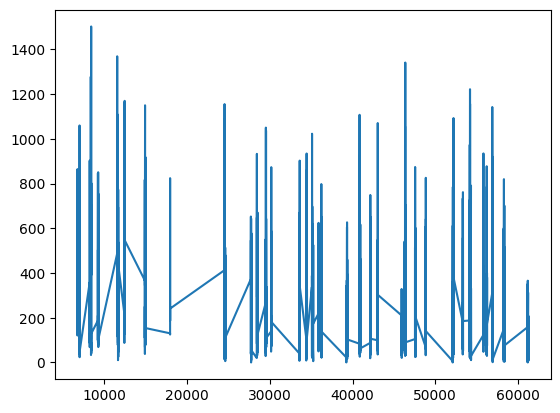

In [137]:
plt.plot(p_state)

In [132]:
d = np.diff(p_events).squeeze()
p_events[d>5]

c:\Users\iii9781\nrem_analysis\.venv\Lib\site-packages\pynapple\core\interval_set.py:524: UserWarning: Converting IntervalSet to numpy.array
  warnings.warn(


  index    start      end
      0  10391.5  11528.1
      1  11673    12033
      2  12445.1  14869.7
      3  21201.5  24461
      4  26161    27693.1
      5  52251    52787
shape: (6, 2), time unit: sec.

In [136]:
sleep[sleep['state'] == state]

index    start    end      state
0        6723.0   6734.0   rem
1        6978.0   6993.0   rem
2        8207.0   8216.0   rem
3        8326.0   8404.0   rem
4        9194.0   9257.0   rem
5        11526.0  11673.0  rem
6        12393.0  12446.0  rem
...      ...      ...      ...
33       56868.0  56942.0  rem
34       58270.0  58386.0  rem
35       61150.0  61254.0  rem
36       62959.0  63008.0  rem
37       63358.0  63507.0  rem
38       64621.0  64724.0  rem
39       69881.0  69890.0  rem
shape: (40, 2), time unit: sec.

In [85]:
d = data[data['mouse_id'] == '111b']
d[d['duration'] > 2]

,mouse_id,state,rate,duration,iei,thr,n_units
68480,111b,wake,10.541447,2.0870,0.9520,204.085285,27
68498,111b,wake,11.561055,3.5560,1.4390,204.085285,27
68512,111b,wake,12.041674,2.3960,1.1300,204.085285,27
68516,111b,wake,10.847346,3.3700,0.3060,204.085285,27
68528,111b,wake,10.555709,2.4140,4.3860,204.085285,27
...,...,...,...,...,...,...,...
86690,111b,rem,25.398538,3.0900,0.8310,360.267196,27
86766,111b,rem,23.721861,2.2030,0.1350,360.267196,27
86782,111b,rem,1.795635,1532.1105,1533.9395,360.267196,27
86886,111b,rem,18.089054,2.1560,0.2250,360.267196,27


In [125]:
mask = np.diff(p_events)>5
p_events[mask.squeeze()]

c:\Users\iii9781\nrem_analysis\.venv\Lib\site-packages\pynapple\core\interval_set.py:524: UserWarning: Converting IntervalSet to numpy.array
  warnings.warn(


  index    start      end
      0  10391.5  11528.1
      1  11673    12033
      2  12445.1  14869.7
      3  21201.5  24461
      4  26161    27693.1
      5  52251    52787
shape: (6, 2), time unit: sec.

In [7]:
summary = (
    data.groupby(["mouse_id", "state"], as_index=False)
        .agg(
            rate_mean=("rate", "mean"),
            rate_sem=("rate", "sem"),
            duration_mean=("duration", "mean"),
            duration_sem=("duration", "sem"),
            iei_mean=("iei", "mean"),
            iei_sem=("iei", "sem"),
        )
)
summary

,mouse_id,state,rate_mean,rate_sem,duration_mean,duration_sem,iei_mean,iei_sem
0,100b,nrem,8.089444,0.018214,0.461834,0.079088,3.434147,0.402732
1,100b,rem,15.549744,0.133438,0.210637,0.012236,74.412604,62.482982
2,100b,wake,8.256870,0.039536,0.181892,0.003489,1.550724,0.038922
3,102b,nrem,5.447736,0.021718,0.596882,0.129333,3.425954,0.395004
4,102b,rem,16.231882,0.208910,0.364306,0.029957,56.156350,24.108117
5,102b,wake,9.651306,0.062612,0.503903,0.091981,8.163508,1.155423
6,106b,nrem,6.748337,0.014118,0.930087,0.250264,4.362384,0.524999
7,106b,rem,12.422581,0.094638,1.791779,1.006847,36.163526,9.357819
8,106b,wake,17.635954,0.025317,0.344404,0.005073,2.318115,0.084068
9,107b,nrem,6.945983,0.013783,0.521299,0.146438,3.192967,0.366278


<Axes: xlabel='state', ylabel='duration'>

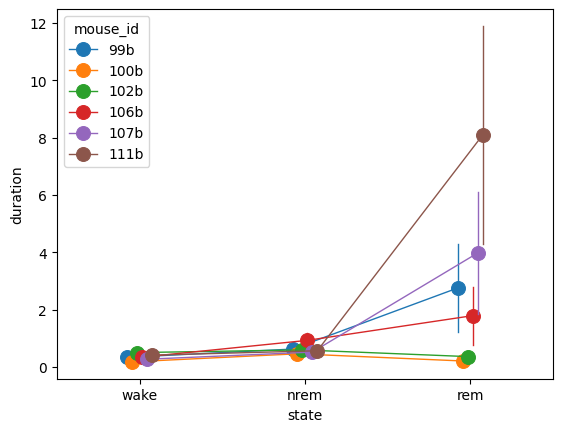

In [65]:
sns.pointplot(
    data=data,
    x="state",
    y="duration",
    errorbar="se",
    order=['wake', 'nrem', 'rem'],
    hue="mouse_id",
    dodge=True,
    linewidth=1,
    markersize=10,
)

<Axes: xlabel='state', ylabel='rate'>

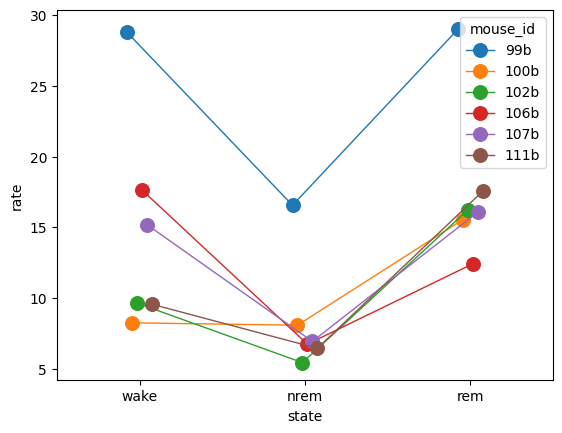

In [75]:
sns.pointplot(
    data=data,
    x="state",
    y="rate",
    errorbar="se",
    order=['wake', 'nrem', 'rem'],
    hue="mouse_id",
    dodge=True,
    linewidth=1,
    markersize=10,
)

<Axes: xlabel='state', ylabel='iei'>

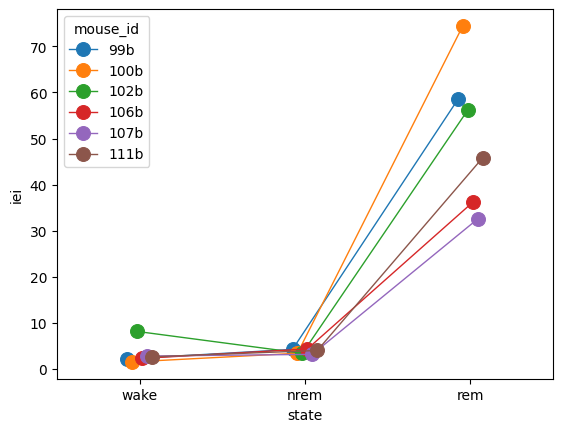

In [84]:
sns.pointplot(
    data=data,
    x="state",
    y="iei",
    errorbar=None,
    order=['wake', 'nrem', 'rem'],
    hue="mouse_id",
    dodge=True,
    linewidth=1,
    markersize=10,
)

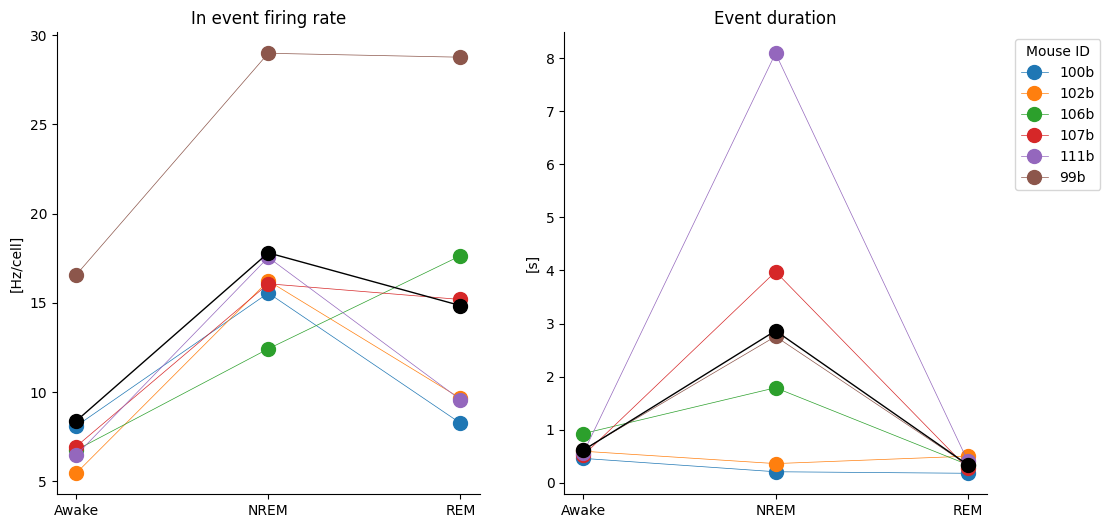

In [17]:
fname = output_dir / "all_mice.png"

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
xlabels = ['Awake', 'NREM', 'REM']

for mouse_id in summary['mouse_id'].unique():
    mouse_data = summary[summary['mouse_id'] == mouse_id]
    axs[0].plot(xlabels, mouse_data['rate_mean'], marker='o', linewidth=0.5, markersize=10, label=mouse_id)
    axs[1].plot(xlabels, mouse_data['duration_mean'], marker='o', linewidth=0.5, markersize=10, label=mouse_id)

axs[0].set_title("In event firing rate")
axs[0].plot(xlabels, summary.groupby('state')['rate_mean'].mean(), marker='o', linewidth=1, color='k', markersize=10)
axs[0].set_ylabel("[Hz/cell]")
# axs[0].set_ylim(0, 25)

axs[1].plot(xlabels, summary.groupby('state')['duration_mean'].mean(), marker='o', linewidth=1, color='k', markersize=10)
axs[1].set_title("Event duration")
axs[1].set_ylabel("[s]")
# axs[1].set_ylim(0, 0.5)
plt.legend(title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# plt.savefig(fname, dpi=300, bbox_inches='tight')

### Per mouse

In [ ]:
def plot_events(mouse_id, event_rates, event_duration, fname=None):
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f"{mouse_id}", fontsize=16)

    axs[0].set_title("In event firing rate")
    for _, unit_rates in event_rates.iterrows():
        axs[0].plot(states, unit_rates, marker='o', linewidth=0.5, color='k', markersize=10)
    axs[0].plot(states, event_rates.mean(), marker='o', linewidth=1, color='r', markersize=10)
    axs[0].set_ylabel("Firing rate (Hz)")

    axs[1].plot(states, event_duration.values(), marker='o', linewidth=0.5, color='k', markersize=10)
    axs[1].set_title("Event duration")
    axs[1].set_ylabel("Event duration (s)")
    if fname is not None:
        plt.savefig(fname, dpi=300, bbox_inches='tight')
    
    return fig, axs

In [102]:
bin_size = 0.001
for mouse_id in MOUSE_IDS_DUAL:
    sleep = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
    turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    cw_units = turn_units[turn_units['is_cw']]

    event_rates = {}
    event_duration = {}

    # Get summed activity
    p = cw_units.count(bin_size=bin_size, time_units="s")
    p = p.sum(axis=1) / bin_size
    p = p.smooth(std=50, time_units="ms")

    for state in states:
        p_state = p.restrict(sleep[sleep['state'] == state])
        thr = p_state.mean() + 1 * p_state.std()
        population_events = p_state.threshold(thr).time_support

        print(mouse_id)
        print(f"{state} population activity: {p_state.mean():.3f} ± {p_state.std():.3f}")
        print(f"{state} population event threshold: {thr:.3f}")
        print(f"{state} detected population events: {len(population_events)}")
        print('--' * 50)

        duration = population_events.end - population_events.start
        result = cw_units.count(ep=population_events).to_numpy() / duration[:, None]
        
        event_rates[state] = np.nanmean(result, axis=0)
        event_duration[state] = duration.mean()

    event_rates = pd.DataFrame(event_rates, index=cw_units.keys())
    f, axs = plot_events(mouse_id, event_rates, event_duration, fname=output_dir / f"{mouse_id}.png")
    plt.close(f)

wake population activity: 124.319 ± 68.469
wake population event threshold: 192.787
wake detected population events: 11543
----------------------------------------------------------------------------------------------------
nrem population activity: 70.647 ± 39.802
nrem population event threshold: 110.449
nrem detected population events: 8326
----------------------------------------------------------------------------------------------------
rem population activity: 129.097 ± 75.540
rem population event threshold: 204.638
rem detected population events: 551
----------------------------------------------------------------------------------------------------
wake population activity: 83.877 ± 52.732
wake population event threshold: 136.609
wake detected population events: 13644
----------------------------------------------------------------------------------------------------
nrem population activity: 60.363 ± 33.725
nrem population event threshold: 94.088
nrem detected population event

### All mice

In [150]:
event_rates = {'wake': [], 'nrem': [], 'rem': []}
event_duration = {'wake': [], 'nrem': [], 'rem': []}
index = []
bin_size = 0.001

for mouse_id in MOUSE_IDS_DUAL:
    sleep = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
    turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    cw_units = turn_units[turn_units['is_cw']]
    
    print(mouse_id)
    if len(cw_units) < 5:
        print(f"{mouse_id} has {len(cw_units)}<5 CW units, skipping...")
        continue

    # Get summed activity
    # p = cw_units.count(bin_size=bin_size, time_units="s")
    p = turn_units.count(bin_size=bin_size, time_units="s")
    p = p.sum(axis=1) / bin_size
    p = p.smooth(std=50, time_units="ms")

    for state in states:
        p_state = p.restrict(sleep[sleep['state'] == state])
        thr = p_state.mean() + 1 * p_state.std()
        population_events = p_state.threshold(thr).time_support

        print(f"    {state} population activity: {p_state.mean():.3f} ± {p_state.std():.3f}")
        print(f"    {state} population event threshold: {thr:.3f}")
        print(f"    {state} detected population events: {len(population_events)}")
        print('--' * 25)

        duration = population_events.end - population_events.start
        # result = cw_units.count(ep=population_events).to_numpy() / duration[:, None]
        result = turn_units.count(ep=population_events).to_numpy() / duration[:, None]
        
        event_rates[state].append(result.mean())
        event_duration[state].append(duration.mean())
    index.append(mouse_id)
event_rates = pd.DataFrame(event_rates, index=index)
event_duration = pd.DataFrame(event_duration, index=index)

99b
    wake population activity: 180.777 ± 86.077
    wake population event threshold: 266.854
    wake detected population events: 13552
--------------------------------------------------
    nrem population activity: 111.402 ± 50.467
    nrem population event threshold: 161.869
    nrem detected population events: 9546
--------------------------------------------------
    rem population activity: 203.219 ± 110.406
    rem population event threshold: 313.625
    rem detected population events: 601
--------------------------------------------------
100b
    wake population activity: 171.570 ± 87.693
    wake population event threshold: 259.262
    wake detected population events: 13368
--------------------------------------------------
    nrem population activity: 106.630 ± 55.552
    nrem population event threshold: 162.182
    nrem detected population events: 9788
--------------------------------------------------
    rem population activity: 218.761 ± 125.421
    rem population e

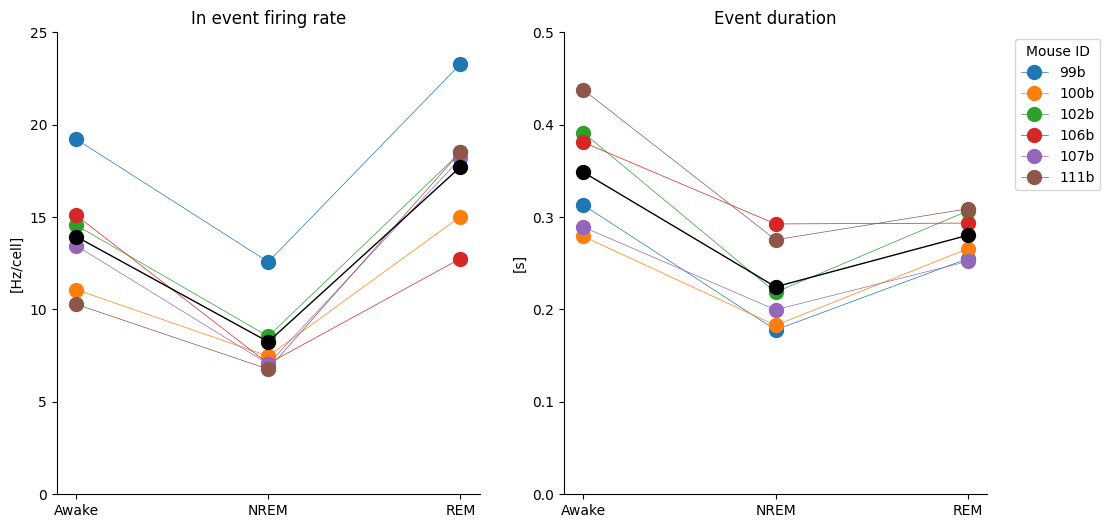

In [159]:
fname = output_dir / "all_mice.png"

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
xlabels = ['Awake', 'NREM', 'REM']

for i in range(event_rates.shape[0]):
    axs[0].plot(xlabels, event_rates.iloc[i], marker='o', linewidth=0.5,  markersize=10, label=index[i])
    axs[1].plot(xlabels, event_duration.iloc[i], marker='o', linewidth=0.5, markersize=10, label=index[i])

axs[0].set_title("In event firing rate")
axs[0].plot(xlabels, event_rates.mean(), marker='o', linewidth=1, color='k', markersize=10)
axs[0].set_ylabel("[Hz/cell]")
# axs[0].set_ylim(0, 25)

axs[1].plot(xlabels, event_duration.mean(), marker='o', linewidth=1, color='k', markersize=10)
axs[1].set_title("Event duration")
axs[1].set_ylabel("[s]")
axs[1].set_ylim(0, 0.5)
plt.legend(title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.savefig(fname, dpi=300, bbox_inches='tight')

In [158]:
mean_rates = event_rates.mean()
sem_rates = event_rates.sem()
mean_duration = event_duration.mean()
sem_duration = event_duration.sem()

for state in states:
    print(f"{state} event rate: {mean_rates[state]:.3f} ± {sem_rates[state]:.3f} Hz")
    print(f"{state} event duration: {mean_duration[state]:.3f} ± {sem_duration[state]:.3f} s")
    print('--' * 25)

wake event rate: 13.948 ± 1.309 Hz
wake event duration: 0.349 ± 0.026 s
--------------------------------------------------
nrem event rate: 8.249 ± 0.902 Hz
nrem event duration: 0.225 ± 0.020 s
--------------------------------------------------
rem event rate: 17.711 ± 1.464 Hz
rem event duration: 0.280 ± 0.011 s
--------------------------------------------------


## Inter-event interval

In [171]:
s = population_events.start
iei = s[1::] - s[0:-1:] # consecutive onset times
print(s[0:-1:])
print(s[0:-1:].shape)
print(s[1::])
print(s[1::].shape)
print(iei)

[ 6723.      6723.1235  6723.9075 ... 64719.0285 64719.5695 64719.8865]
(1385,)
[ 6723.1235  6723.9075  6724.7315 ... 64719.5695 64719.8865 64722.0535]
(1385,)
[0.1235 0.784  0.824  ... 0.541  0.317  2.167 ]


In [172]:
event_iei_mean = {'wake': [], 'nrem': [], 'rem': []}
event_iei_sem = {'wake': [], 'nrem': [], 'rem': []}
index = []
bin_size = 0.001

for mouse_id in MOUSE_IDS_DUAL:
    sleep = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
    turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    cw_units = turn_units[turn_units['is_cw']]
    
    print(mouse_id)
    if len(cw_units) < 5:
        print(f"{mouse_id} has {len(cw_units)}<5 CW units, skipping...")
        continue

    # Get summed activity
    p = cw_units.count(bin_size=bin_size, time_units="s")
    # p = turn_units.count(bin_size=bin_size, time_units="s")
    p = p.sum(axis=1) / bin_size
    p = p.smooth(std=50, time_units="ms")

    for state in states:
        p_state = p.restrict(sleep[sleep['state'] == state])
        thr = p_state.mean() + 1 * p_state.std()
        population_events = p_state.threshold(thr).time_support
        iei = population_events.start[1::] - population_events.start[0:-1:]
        event_iei_mean[state].append(iei.mean())
        event_iei_sem[state].append(iei.std() / np.sqrt(len(iei)))
    index.append(mouse_id)

event_iei_mean = pd.DataFrame(event_iei_mean, index=index)
event_iei_sem = pd.DataFrame(event_iei_sem, index=index)

99b


KeyboardInterrupt: 